# Lesson 8 — Bayesian Optimisation Loop with GP

This lesson combines everything from Lessons 6 and 7 into one complete algorithm:

```
1. Initialise: sample n_init points using LHS → evaluate f
2. Fit GP to all (X, y) pairs
3. Maximise EI over a candidate set → x_next
4. Evaluate the real function: y_next = f(x_next)   ← the expensive step
5. Add (x_next, y_next) to the dataset
6. Repeat steps 2–5 until budget is exhausted
```

The loop spends the evaluation budget as efficiently as possible by always choosing the point with the highest expected improvement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

## Benchmark functions, GP, and acquisition (from Lessons 6–7)

In [2]:
def forrester(x):
    x = np.asarray(x).ravel()
    return (6*x - 2)**2 * np.sin(12*x - 4)

def branin_norm(X):
    X = np.atleast_2d(X)
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    a, b, c = 1.0, 5.1/(4*np.pi**2), 5/np.pi
    r, s, t = 6.0, 10.0, 1/(8*np.pi)
    return a*(x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s

def matern52(X1, X2, length_scale=1.0, signal_var=1.0):
    X1 = np.atleast_2d(X1); X2 = np.atleast_2d(X2)
    diff = X1[:, None, :] - X2[None, :, :]
    r = np.sqrt(np.sum(diff**2, axis=-1))
    s = np.sqrt(5) * r / length_scale
    return signal_var * (1 + s + s**2/3) * np.exp(-s)

def gp_predict(X_train, y_train, X_test, kernel_fn, noise=1e-4):
    K    = kernel_fn(X_train, X_train) + noise * np.eye(len(X_train))
    Ks   = kernel_fn(X_test, X_train)
    Kss  = kernel_fn(X_test, X_test)
    L    = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    mu   = Ks @ alpha
    v    = np.linalg.solve(L, Ks.T)
    std  = np.sqrt(np.maximum(np.diag(Kss) - np.sum(v**2, axis=0), 0))
    return mu, std

def acq_ei(mu, std, f_best, xi=0.01):
    Z = (f_best - xi - mu) / (std + 1e-9)
    return np.maximum((f_best - xi - mu) * norm.cdf(Z) + std * norm.pdf(Z), 0)

FORRESTER_MIN = forrester(np.linspace(0, 1, 10000)).min()
BRANIN_MIN    = 0.397887
print(f"Forrester true minimum ≈ {FORRESTER_MIN:.4f}")
print(f"Branin true minimum   ≈ {BRANIN_MIN:.4f}")

Forrester true minimum ≈ -6.0207
Branin true minimum   ≈ 0.3979


## Part 1 — Latin Hypercube Sampling

With a small budget the initial design matters a lot. **Latin Hypercube Sampling (LHS)** divides each axis into $n$ equal strata and places exactly one point per stratum — guaranteeing uniform coverage regardless of random chance.

Random sampling can leave gaps or clusters by chance. With 20 points in 2D, those gaps waste budget before the BO loop even starts.

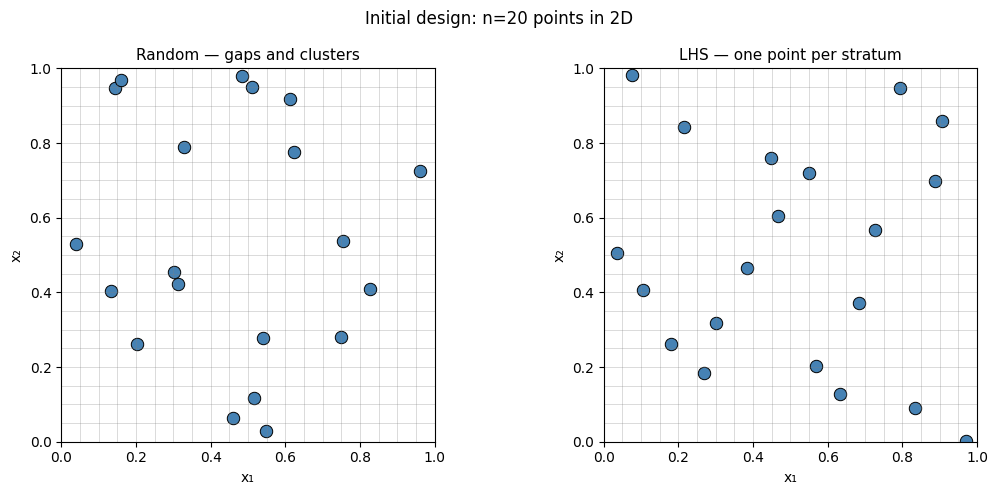

In [8]:
def lhs(n, d, seed=None):
    r = np.random.default_rng(seed)
    result = np.zeros((n, d))
    for j in range(d):
        result[:, j] = (r.permutation(n) + r.uniform(0, 1, n)) / n
    return result

n_pts      = 20
lhs_pts    = lhs(n_pts, 2, seed=0)
random_pts = np.random.default_rng(1).uniform(0, 1, (n_pts, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, pts, title in zip(axes,
    [random_pts, lhs_pts],
    ["Random — gaps and clusters", "LHS — one point per stratum"]):
    ax.scatter(pts[:, 0], pts[:, 1], s=80, color="steelblue",
               edgecolors="black", linewidths=0.7)
    for k in range(n_pts + 1):
        v = k / n_pts
        ax.axvline(v, color="gray", linewidth=0.4, alpha=0.5)
        ax.axhline(v, color="gray", linewidth=0.4, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
    ax.set_aspect("equal")

plt.suptitle(f"Initial design: n={n_pts} points in 2D", fontsize=12)
plt.tight_layout()
plt.show()

**Try it:** Increase `n_pts` to 50. Is the LHS advantage still visible? Now try `n_pts=5` — with very few points, the difference becomes critical.

## Part 2 — The full BO loop

We implement the complete loop and snapshot the GP state at four different evaluation counts.

In [9]:
kern_1d = lambda X1, X2: matern52(X1, X2, length_scale=0.25, signal_var=4.0)

def run_bo_1d(n_init, budget, kern_fn, noise=0.01, xi=0.01, seed=0, snapshot_at=None):
    X   = lhs(n_init, 1, seed=seed)
    y   = forrester(X)
    x_cand = np.linspace(0, 1, 500).reshape(-1, 1)
    best_history = [float(y.min())]
    snapshots    = {}
    snap_set     = set(snapshot_at or [])

    for i in range(budget - n_init):
        mu, std = gp_predict(X, y, x_cand, kern_fn, noise)
        f_best  = float(y.min())
        ei_vals = acq_ei(mu, std, f_best, xi=xi)
        idx     = int(np.argmax(ei_vals))

        if i in snap_set:
            snapshots[i] = dict(X=X.copy(), y=y.copy(),
                                mu=mu, std=std, ei=ei_vals,
                                x_next=float(x_cand[idx, 0]),
                                f_best=f_best, n_eval=n_init+i)

        X = np.vstack([X, x_cand[[idx]]])
        y = np.append(y, forrester(x_cand[[idx]]).item())
        best_history.append(float(y.min()))

    return X, y, best_history, snapshots

print("BO loop function defined.")

BO loop function defined.


**Try it:** Change `seed=1` or `seed=2`. Does the loop converge from a different starting point? Notice how the uncertainty band collapses around each new evaluation.

## Part 3 — Convergence curve

We run the BO loop 10 times from different random seeds and plot the mean ± std of the best-found value vs evaluation count.

This is the standard way to report BO results in papers.

In [ ]:
n_runs = 10
budget = 30
n_init = 5

bo_curves = []
for seed in range(n_runs):
    _, _, hist, _ = run_bo_1d(n_init, budget, kern_1d, seed=seed)
    bo_curves.append(hist)

bo_arr = np.array(bo_curves)
iters  = np.arange(bo_arr.shape[1]) + n_init

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iters, bo_arr.mean(axis=0), color="steelblue", linewidth=2.5, label="GP-BO mean")
ax.fill_between(iters,
                bo_arr.mean(axis=0) - bo_arr.std(axis=0),
                bo_arr.mean(axis=0) + bo_arr.std(axis=0),
                alpha=0.2, color="steelblue", label="±1 std")
for c in bo_curves:
    ax.plot(iters, c, color="steelblue", linewidth=0.5, alpha=0.3)
ax.axhline(FORRESTER_MIN, color="tomato", linestyle="--", linewidth=1.5,
           label=f"True min = {FORRESTER_MIN:.3f}")
ax.set_title(f"GP-BO convergence ({n_runs} runs, budget={budget})")
ax.set_xlabel("Evaluations"); ax.set_ylabel("Best f found")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 4 — BO vs random search

Random search is a strong baseline on low-dimensional problems. We compare it directly to see how many evaluations BO saves.

In [ ]:
random_curves = []
for seed in range(n_runs):
    r = np.random.default_rng(seed + 100)
    X_rand = r.uniform(0, 1, (budget, 1))
    y_rand = forrester(X_rand)
    random_curves.append([float(y_rand[:k+1].min()) for k in range(budget)])

rand_arr = np.array(random_curves)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(np.arange(1, budget+1), rand_arr.mean(axis=0),
        color="tomato", linewidth=2.5, label="Random search")
ax.fill_between(np.arange(1, budget+1),
                rand_arr.mean(axis=0) - rand_arr.std(axis=0),
                rand_arr.mean(axis=0) + rand_arr.std(axis=0),
                alpha=0.2, color="tomato")

ax.plot(iters, bo_arr.mean(axis=0),
        color="steelblue", linewidth=2.5, label="GP-BO (EI, ξ=0.01)")
ax.fill_between(iters,
                bo_arr.mean(axis=0) - bo_arr.std(axis=0),
                bo_arr.mean(axis=0) + bo_arr.std(axis=0),
                alpha=0.2, color="steelblue")

ax.axhline(FORRESTER_MIN, color="black", linestyle="--", linewidth=1.2,
           label=f"True min = {FORRESTER_MIN:.3f}")
ax.set_title(f"GP-BO vs Random Search on Forrester ({n_runs} runs, budget={budget})")
ax.set_xlabel("Evaluations"); ax.set_ylabel("Best f found")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Try it:** Replace EI with PI (`xi=0`) in the BO loop. Does it converge faster or slower? The GP-BO advantage over random search should still hold, but PI may plateau sooner due to over-exploitation.

## Part 5 — 2D BO on Branin

The Branin function has three global minima all at $f^* \approx 0.398$. GP-BO should find one of them within 40 evaluations starting from 10 LHS points.

In [ ]:
kern_2d = lambda X1, X2: matern52(X1, X2, length_scale=0.3, signal_var=50.0)

def run_bo_2d(n_init, budget, kern_fn, noise=0.1, xi=0.01, seed=0):
    X      = lhs(n_init, 2, seed=seed)
    y      = branin_norm(X)
    g      = np.linspace(0, 1, 30)
    G1, G2 = np.meshgrid(g, g)
    x_cand = np.column_stack([G1.ravel(), G2.ravel()])
    best_history = [float(y.min())]
    for _ in range(budget - n_init):
        mu, std = gp_predict(X, y, x_cand, kern_fn, noise)
        ei_vals = acq_ei(mu, std, float(y.min()), xi=xi)
        idx     = int(np.argmax(ei_vals))
        x_next  = x_cand[[idx]]
        X       = np.vstack([X, x_next])
        y       = np.append(y, branin_norm(x_next).item())
        best_history.append(float(y.min()))
    return X, y, best_history

budget_2d = 40
n_init_2d = 10
n_runs_2d = 5

bo_curves_2d = []
X_final, y_final = None, None
for seed in range(n_runs_2d):
    X_f, y_f, hist = run_bo_2d(n_init_2d, budget_2d, kern_2d, seed=seed)
    bo_curves_2d.append(hist)
    if seed == 0:
        X_final, y_final = X_f, y_f

bo_2d_arr = np.array(bo_curves_2d)
iters_2d  = np.arange(bo_2d_arr.shape[1]) + n_init_2d

g_plot = np.linspace(0, 1, 80)
G1p, G2p = np.meshgrid(g_plot, g_plot)
z_true = branin_norm(np.column_stack([G1p.ravel(), G2p.ravel()])).reshape(80, 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cf = axes[0].contourf(G1p, G2p, z_true, levels=25, cmap="viridis")
plt.colorbar(cf, ax=axes[0])
axes[0].scatter(X_final[:n_init_2d, 0], X_final[:n_init_2d, 1],
                color="white", s=40, edgecolors="gray", linewidths=0.7,
                zorder=5, label=f"LHS init (n={n_init_2d})")
axes[0].scatter(X_final[n_init_2d:, 0], X_final[n_init_2d:, 1],
                color="red", s=60, edgecolors="black", linewidths=0.7,
                zorder=6, label="BO evaluations")
axes[0].set_title("Branin — training points (one run)")
axes[0].set_xlabel("x₁"); axes[0].set_ylabel("x₂")
axes[0].legend(fontsize=8)

axes[1].plot(iters_2d, bo_2d_arr.mean(axis=0), color="steelblue", linewidth=2.5, label="GP-BO")
axes[1].fill_between(iters_2d,
                     bo_2d_arr.mean(axis=0) - bo_2d_arr.std(axis=0),
                     bo_2d_arr.mean(axis=0) + bo_2d_arr.std(axis=0),
                     alpha=0.2, color="steelblue")
axes[1].axhline(BRANIN_MIN, color="tomato", linestyle="--", linewidth=1.5,
                label=f"True min ≈ {BRANIN_MIN}")
axes[1].set_title(f"Convergence ({n_runs_2d} runs, budget={budget_2d})")
axes[1].set_xlabel("Evaluations"); axes[1].set_ylabel("Best f found")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("2D GP-BO on Branin", fontsize=12)
plt.tight_layout()
plt.show()

**Try it:** Increase `budget_2d` to 60. Does BO reliably reach the true minimum (≈ 0.398)? The Branin has 3 global minima — can you spot BO finding different ones across seeds?

## Part 6 — Effect of initial design size

With a fixed total budget, spending more on LHS init means fewer BO iterations — and vice versa. The right balance depends on the function smoothness and dimension.

In [ ]:
total_budget = 25
n_runs_6     = 8
n_inits      = [3, 5, 10]
colors       = ["tomato", "steelblue", "green"]

fig, ax = plt.subplots(figsize=(9, 5))

for n_init_val, color in zip(n_inits, colors):
    curves = []
    for seed in range(n_runs_6):
        _, _, hist, _ = run_bo_1d(n_init_val, total_budget, kern_1d, seed=seed)
        curves.append(hist)
    max_len = max(len(c) for c in curves)
    padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves])
    evals   = np.arange(max_len) + n_init_val
    ax.plot(evals, padded.mean(axis=0), color=color, linewidth=2.5,
            label=f"n_init = {n_init_val}")
    ax.fill_between(evals,
                    padded.mean(axis=0) - padded.std(axis=0),
                    padded.mean(axis=0) + padded.std(axis=0),
                    alpha=0.15, color=color)

ax.axhline(FORRESTER_MIN, color="black", linestyle="--", linewidth=1.2,
           label=f"True min = {FORRESTER_MIN:.3f}")
ax.set_title(f"Effect of initial design size (total budget = {total_budget}, {n_runs_6} runs)")
ax.set_xlabel("Total evaluations used"); ax.set_ylabel("Best f found")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Try it:** Set `n_init_val=20` with `total_budget=25` — only 5 BO iterations. Does the GP still improve much over the initial LHS design?

## Summary

```
GP-BO algorithm:

  X, y  ← LHS(n_init)  +  f(X)
  repeat until budget exhausted:
      μ, σ      ← GP_predict(X, y, x_candidates)
      x_next    ← argmax EI(μ, σ, f_best)
      y_next    ← f(x_next)            # ← expensive!
      X, y      ← append(x_next, y_next)
```

| Component | Lesson | Choice here |
|---|---|---|
| Surrogate | 6 | Matern-5/2 GP |
| Acquisition | 7 | EI with ξ=0.01 |
| Init design | 8 | LHS with n_init=5 |
| Candidate opt | 8 | Dense grid (1D/2D only) |

**Next lesson:** Replace the GP surrogate with a neural network. PyTorch first (Lesson 9), then MC Dropout (Lesson 10) and Deep Ensembles (Lesson 11).